# 1. **Introduction & Objectives**

This project aims to perform customer segmentation for a mall based on their annual income and spending habits. The goal is to identify distinct groups of customers to help the mall's marketing team develop targeted strategies. By understanding these segments, the mall can offer personalized promotions, optimize store layouts, and enhance customer satisfaction and loyalty.

**Key Objective:**

To group customers into meaningful segments using unsupervised machine learning(clustering).

To analyze the characteristics of each customer segment.

To provide actionable business insights based on the segmentation.

# 2. **Data overview**

The dataset used is the Mall Customers dataset, containing information about 200 customers. It includes the following features:

 **CustomerID:** Unique identifier for each customer.

**Gender:** Gender of the customer (Male/Female).

**Age:** Age of the customer.

**Annual Income (k$):** Annual income of the customer in thousands of dollars.

**Spending Score (1-100):** A score assigned by the mall based on customer behavior and spending nature.

For this analysis, we will primarily focus on Annual Income (k$) and Spending Score (1-100) as the key features for clustering, as they directly relate to purchasing power and behavior.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


#Importing neccesary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
# considering the relevant features for clustering

features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Selecting and Standardizing Features

Before applying the K-Means clustering algorithm, we need to select the features that will be used for segmentation. In this case, we will focus on 'Age', 'Annual Income (k$)', and 'Spending Score (1-100)'.

Since these features have different scales, it's important to standardize them. Standardization involves transforming the data so that it has a mean of 0 and a standard deviation of 1. This prevents features with larger values from dominating the distance calculations in the clustering algorithm. We will use `StandardScaler` from scikit-learn for this purpose.

In [ ]:
print("Selected feature for clustering")
print(features)

Selected feature for clustering
     Age  Annual Income (k$)  Spending Score (1-100)
0     19                  15                      39
1     21                  15                      81
2     20                  16                       6
3     23                  16                      77
4     31                  17                      40
..   ...                 ...                     ...
195   35                 120                      79
196   45                 126                      28
197   32                 126                      74
198   32                 137                      18
199   30                 137                      83

[200 rows x 3 columns]


In [ ]:
# Performing stadardization to ensure contribution of each features in analysis equally
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_features

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

#The scatter plot reveals clear customer groupings based on income and spending. Five distinct segments are visible:

#High income, low spending (bottom-right)

#High income, high spending (top-right)

#Medium income, medium spending (center)

#Low income, high spending (top-left)

#Low income, low spending (bottom-left)




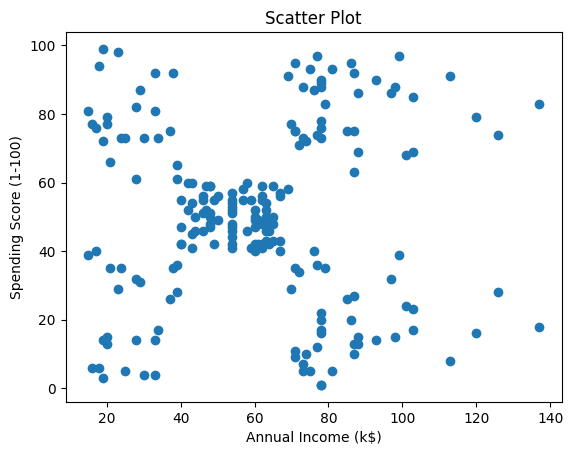

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.title('Scatter Plot')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [ ]:
!pip install kneed

# Storing the scaled features into a variable `X` for convenience in subsequent steps.

In [ ]:
X = scaled_features # storing this into an  X for convinience

# Finding the optimal number of clusters using the Elbow Method

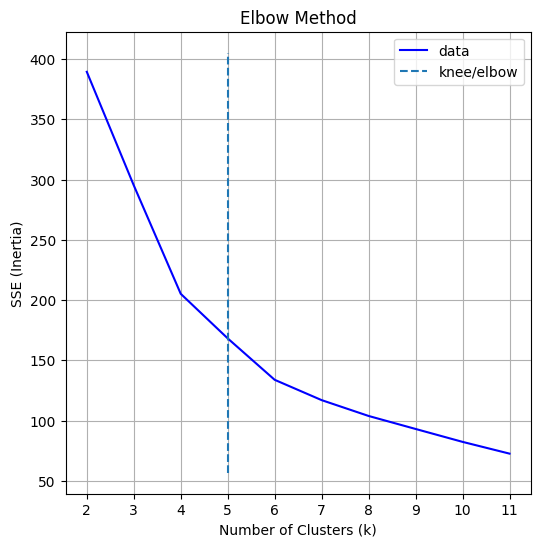

Optimal number of clusters: 5


In [ ]:
from sklearn.cluster import KMeans

from kneed import KneeLocator # using knee locater to find optimal no of cluters

sse = []
min_k = 2
max_k = 12

for k in range(min_k, max_k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)


kl = KneeLocator(range(min_k, max_k), sse, curve="convex", direction="decreasing")

# Plot the Elbow
kl.plot_knee()
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.xticks(range(min_k, max_k))
plt.title('Elbow Method')
plt.grid(True)
plt.show()

optimal_k = kl.knee
print("Optimal number of clusters:", optimal_k)

#Performing K-Means clustering with the optimal number of clusters and transforming centroids back to original scale

In [ ]:
kmeans = KMeans(
    n_clusters=optimal_k,        # This is from KneeLocator
    random_state=42,
    n_init=10,
    init='k-means++',
    verbose=1
)

# Fit to your standardized features
kmeans.fit(X)

# Get cluster labels
labels = kmeans.labels_
 # getting cluster into original scale
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

Initialization complete
Iteration 0, inertia 272.61596113342245.
Iteration 1, inertia 192.8896309588348.
Iteration 2, inertia 178.77577991882114.
Iteration 3, inertia 174.2842351594154.
Iteration 4, inertia 171.46466782051036.
Iteration 5, inertia 170.1580069064266.
Iteration 6, inertia 169.89149793438568.
Converged at iteration 6: strict convergence.
Initialization complete
Iteration 0, inertia 234.09863049263151.
Iteration 1, inertia 181.44871639064846.
Iteration 2, inertia 178.27627901537957.
Iteration 3, inertia 177.13411567875883.
Iteration 4, inertia 175.46508119374488.
Iteration 5, inertia 172.9188628695242.
Iteration 6, inertia 170.5236094696752.
Iteration 7, inertia 168.42140769366293.
Iteration 8, inertia 168.2475801755683.
Converged at iteration 8: strict convergence.
Initialization complete
Iteration 0, inertia 266.22967868405897.
Iteration 1, inertia 207.60210889095615.
Iteration 2, inertia 195.38156789169904.
Iteration 3, inertia 190.17926112929965.
Iteration 4, inertia 1

In [ ]:
# getting the labels

labels

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1,
       0, 1, 4, 1, 1, 1, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 4, 1,
       4, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1,
       1, 4, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 4, 4, 1, 4, 1, 4, 4, 4, 4,
       4, 1, 3, 1, 1, 1, 4, 4, 4, 4, 1, 3, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 4, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

In [ ]:
df['Cluster'] = labels # adding clusters label to dataframe
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()# average for each group

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


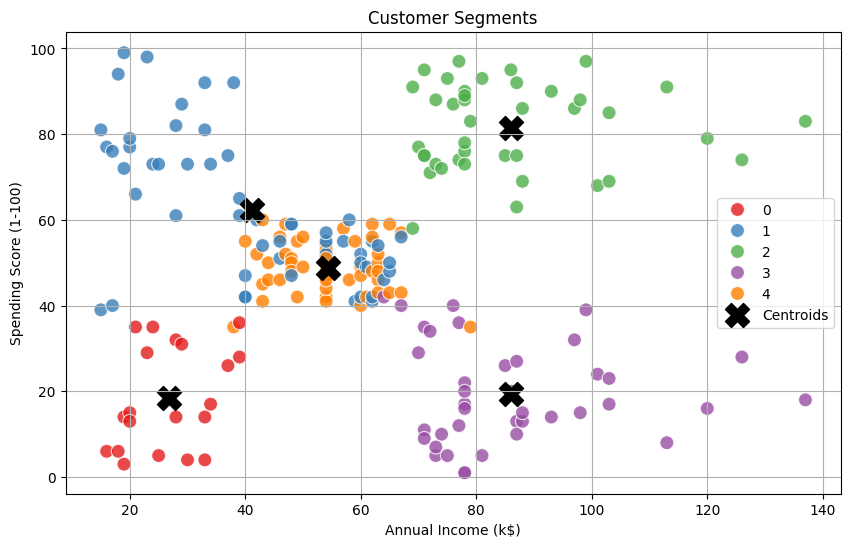

In [ ]:
# plotting cluters for kmeans clustering

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=100,
    alpha=0.8
)

plt.scatter(
    centroids[:, 1],    # Income (index 1)
    centroids[:, 2],    # Spending Score (index 2)
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()


## Business Recommendation & insights

Based on the K-Means clustering with 5 clusters, we have identified the following customer segments:

*   **Cluster 0: Low Income, Low Spending:** This group consists of customers with lower annual incomes and lower spending scores. They may require targeted promotions or incentives to encourage more spending.
*   **Cluster 1: Medium Income, High Spending:** These customers have moderate incomes but high spending scores. They represent a valuable segment that responds well to the mall's offerings. They could be targeted with loyalty programs or exclusive offers.
*   **Cluster 2: High Income, High Spending:** This segment comprises customers with high annual incomes and high spending scores. They are the most valuable customers and should be targeted with premium products, services, and personalized experiences.
*   **Cluster 3: High Income, Low Spending:** These customers have high incomes but low spending scores. There might be untapped potential in this group. Understanding their preferences and barriers to spending could lead to strategies for increasing their engagement.
*   **Cluster 4: Medium Income, Medium Spending:** This is a large and diverse group with moderate incomes and spending habits. They could be targeted with a broad range of promotions and product offerings.

Understanding these distinct segments allows the mall to tailor marketing strategies, product placements, and customer service to better meet the needs and preferences of each group, ultimately leading to increased customer satisfaction and revenue.